# Advanced CNN Architectures

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

### Load CIFAR-10 Dataset

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


### Filter Only Cats & Dogs

In [4]:
train_filter = np.where((y_train == 3) | (y_train == 5))[0]
test_filter = np.where((y_test == 3) | (y_test == 5))[0]

X_train, y_train = X_train[train_filter], y_train[train_filter]
X_test, y_test = X_test[test_filter], y_test[test_filter]

# Convert labels
# Cat = 0
# Dog = 1

y_train = (y_train == 5).astype(int)
y_test = (y_test == 5).astype(int)

print("Filtered Training Shape:", X_train.shape)

Filtered Training Shape: (10000, 32, 32, 3)


### Resize Images for ResNet50

In [5]:
X_train = tf.image.resize(X_train, (224, 224))
X_test = tf.image.resize(X_test, (224, 224))

### Normalize Data

In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Visualize Sample Image

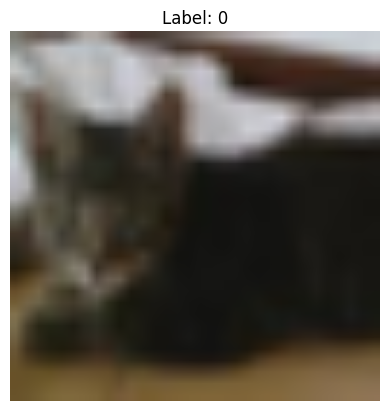

In [8]:
plt.imshow(X_train[0])
plt.title("Label: " + str(y_train[0][0]))
plt.axis("off")
plt.show()

### Load Pretrained ResNet50

In [11]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

### Freeze Base Layers

In [12]:
for layer in base_model.layers:
    layer.trainable = False

### Build Transfer Learning Model

In [13]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

### Compile Model

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Model Summary

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Train Model

In [16]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=2,
    batch_size=32
)

Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 411s 1s/step - accuracy: 0.5174 - loss: 0.7059 - val_accuracy: 0.5255 - val_loss: 0.6878
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 393s 1s/step - accuracy: 0.5217 - loss: 0.6973 - val_accuracy: 0.5000 - val_loss: 0.7636


### Evaluate Model

In [17]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Validation Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 806ms/step - accuracy: 0.5000 - loss: 0.7636
Validation Accuracy: 0.5


### Plot Accuracy

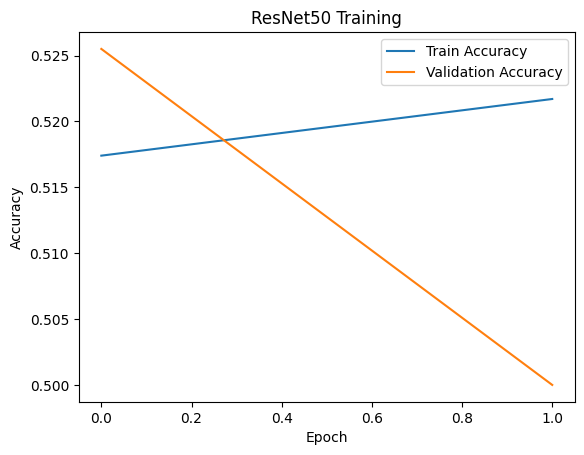

In [18]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training")

plt.legend()
plt.show()

### Plot Loss

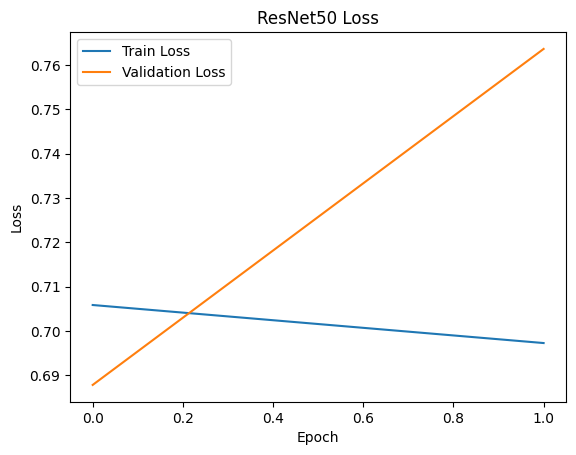

In [19]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss")

plt.legend()
plt.show()